In [23]:
import torch
import torch.nn as nn 
from PIL import Image
import shutil
import glob
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.utils.tensorboard import SummaryWriter
from torchvision.datasets import ImageFolder
from torchvision import transforms , models
from data_transform import offset_crop, LoadUint16TIff, customVal,CustomDataset, sample_gaussian_in_range, clip, gamma_enh
import os 
import numpy as np
import matplotlib.pyplot as plt 

In [24]:
import shutil
# for subdirectories
def copy_subdir(root_dir, dst_dir):
# root_dir ="/home/sphere/Morpheus/new_train_DATA/Fighter/mig_31_body_scale2_0.9ham"
    subdir = os.listdir(root_dir)
    
# dst_dir ="Bomber_fighter_dyn/train/fighter"
    for i in subdir:
        ssdir = os.path.join(root_dir, i)
        image_paths = glob.glob(ssdir+'/*')
        for im_name in image_paths:
            shutil.copy2(im_name, dst_dir)
    print(f"Saved at {dst_dir}")

def copy_images(root_dir, dst_dir):
    images = glob.glob(root_dir+'/*')
    for image in images:
        shutil.copy2(image, dst_dir)
    print(f"saved at {dst_dir}")

In [45]:
dd = "All_data_classification/transporter/train"
copy_images("/home/sphere/Morpheus/new_train_DATA/Transporter/c130_azamb_3.24_0.6pix_0.7ham", dd)

saved at All_data_classification/transporter/train


In [44]:
## Create Dataset
import glob
def rename_images(image_dir):
    '''
    Rename images on the basis of the directory name 
    
    '''
    image_paths = glob.glob(image_dir+'/*')
    for image in image_paths:
        basename = os.path.basename(image)
        angle = basename.split('_')[-3][2:]
        dirname = os.path.basename(image_dir)
        new_name = os.path.join(dirname+"_"+angle+".png")
        os.rename(image, os.path.join(image_dir, new_name))
    print('done')
image_dir = "/home/sphere/Morpheus/new_train_DATA/Transporter/c130_azamb_3.24_0.6pix_0.7ham"
rename_images(image_dir)

done


### HyperParameter and Directory

In [27]:
mdir = "/home/sphere/Morpheus/new_train_DATA/Civilian"
dirs  = os.listdir(mdir)
for di in dirs:
    image_dir = os.path.join(mdir, di)
    rename_images(image_dir)

done
done
done
done
done
done


In [6]:
train_dir = "Bomber_fighter_dyn/train"
val_dir = "Bomber_fighter_dyn/val"
checkpoint_dir = "checkpoint_FB"

batch_size = 16
num_classes =2
num_epochs=100
learning_rate =5e-4
checkpoint_name = f"experimtent2_{num_epochs}_{batch_size}_dropout0.35_weight_decay"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
writer = SummaryWriter(f"fighter_bomber_runs/experiment3_{num_epochs}_{batch_size}_dropout0.35_weight_decay")


### Augmentation

In [7]:
def mig_aug_train(gamma_stretch = [0.5, 1], additive = [0.7, 1.5]):
    """
    Perfroms radiometric augmentation to the image. randomly assign  the parameters of the image non-linear enhancement and 
    noise floor within a limit

    Parameters
    ------------------

    gamma_stretch: limit for non linear enhancement
    additive:  limit for the noise floor 
    """
    def augmentation(img):
        arr = img.numpy()
        arr =(arr - arr.min())/(arr.max() - arr.min())
        gst = sample_gaussian_in_range(np.array(gamma_stretch).mean(), 1.5, gamma_stretch[0], gamma_stretch[1])
        add = sample_gaussian_in_range(np.array(additive).mean(), 1.5, additive[0], additive[-1])
        arr = clip(gamma_enh(arr, gst)+ np.random.gamma(add, 1/20, arr.shape), min =1 ,max = 99.25)
        if arr.ndim ==2:
            arr = np.stack([arr,arr, arr], axis = 0)
        img_out = torch.from_numpy(arr.astype(np.float32))
        return img_out

    return augmentation



def tu_aug_train( paraml = [0.7, 1.1] ,g_enh = [0.35, 1], clutter = [0.7, 1.8], percentiles = [0.25, 99.5]):
    # Convert tensor image to numpy array
    def apply_gamma(img):
        arr = img.numpy()

        # normalize to 0..1 if needed
        arr /= arr.max() + 1e-8

        # gamma correction
        param = sample_gaussian_in_range((paraml[0]+paraml[1])/2, 1.5,low = paraml[0], high =paraml[-1])
        enh = sample_gaussian_in_range((g_enh[0]+g_enh[1])/2, 1.5,low= g_enh[0], high=g_enh[-1])
        cl = sample_gaussian_in_range((clutter[0]+clutter[1])/2, 1.5, clutter[0], clutter[-1])
        
        cl_denom = sample_gaussian_in_range(15,sigma=1.5,low = 10, high=20)
        
        # percentile clipping
        # lo = np.percentile(arr, minp)
        # hi = np.percentile(arr, maxp)
        # arr = np.clip(arr, lo, hi)

        # # scale 0..1
        # arr = (arr - arr.min()) / (arr.max() - arr.min() + 1e-8)
        arr = clip(gamma_enh(arr*np.random.gamma(param, 1/20),enh, arr.shape) + np.random.gamma(cl, 1/cl_denom, arr.shape))
        if arr.ndim == 2:
            arr = np.stack([arr,arr, arr], axis = 0)

        # convert back to PIL image if needed
        img_out = torch.from_numpy(arr.astype(np.float32))
        return img_out

    return apply_gamma
def hel_aug_train(mgam1 = [3,7], mgam2=[15,20], agamma1= [3,7], agamma2=[40,70], cl= [0.3, 0.8]):
    def augmentation(img):
        arr = img.numpy()
        arr = (arr-arr.min())/(arr.max()- arr.min())
        mgam1_val = sample_gaussian_in_range(np.array(mgam1).mean(), 1.5, mgam1[0], mgam1[-1])
        mgam2_val = sample_gaussian_in_range(np.array(mgam2).mean(),1.5, mgam2[0], mgam2[-1])
        agamma1_val = sample_gaussian_in_range(np.array(agamma1).mean(), 1.5, agamma1[0], agamma1[-1])
        agamma2_val = sample_gaussian_in_range(np.array(agamma2).mean(), 1.5, agamma2[0], agamma2[-1])
        # cv2.resize(clip(gamma(sim* np.random.gamma(4,1/20,sim.shape),0.8) + np.random.gamma(.6, 1/20, sim.shape), min=1,max = 99.25),None, fx = 1, fy =1, interpolation =cv2.INTER_AREA)
        arr = clip(gamma_enh(arr*np.random.gamma(mgam1_val, 1/mgam2_val), 0.4) + np.random.gamma(agamma1_val, 1/agamma2_val,arr.shape),min = 1, max = 99.25)
        arr = arr
        if arr.ndim ==2:
            arr = np.stack([arr, arr, arr], axis = 0)
        img_out = torch.from_numpy(arr.astype(np.float32))
        return img_out
    return augmentation


In [8]:
## Transforms

train_class_transform = {"fighter": transforms.Compose([transforms.Lambda(lambda img: offset_crop(img)(img)), 
                                    transforms.ToTensor(), 
                                    transforms.Lambda(mig_aug_train()),
                                    transforms.Normalize(mean = [0.485, 0.456, 0.406],std = [0.229, 0.224,0.225])]),
                        "Tu_95": transforms.Compose([transforms.Lambda(lambda img: offset_crop(img)(img)),
                                    transforms.ToTensor(), 
                                    transforms.Lambda(tu_aug_train()),
                                    transforms.Normalize(mean= [0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])]),
                        "helicopter": transforms.Compose([transforms.Lambda(lambda img: offset_crop(img, crop_size=85, offset_y=17)(img)), 
                                        transforms.ToTensor(),
                                        transforms.Lambda(hel_aug_train()), 
                                        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.224])])}
val_class_transform = {"fighter": transforms.Compose([LoadUint16TIff(gamma=1, minp=2, maxp=98, img_size=128),
                                   transforms.Normalize(mean=[0.485,0.456,0.406], std = [0.229, 0.224, 0.225]) ]),
                        "Tu_95": transforms.Compose([LoadUint16TIff(gamma =1, minp =2, maxp = 98, img_size =128),
                                transforms.Normalize(mean=[0.485,0.456,0.406], std = [0.229, 0.224, 0.225])]),
                         "helicopter": transforms.Compose([LoadUint16TIff(gamma =1, minp = 2, maxp=98, img_size=128),
                                                          transforms.Normalize(mean=[0.485, 0.456, 0.406], std =[0.229, 0.224, 0.225])])}

In [9]:
train_dataset = CustomDataset(root_dir = train_dir, class_transforms = train_class_transform)
val_dataset  = customVal(root_dir = val_dir, class_transform = val_class_transform)
train_loader = DataLoader(train_dataset, batch_size = 64, shuffle = True)
val_loader = DataLoader(val_dataset, batch_size = 32, shuffle = False)

In [18]:
train_im , train_labels = next(iter(train_loader))
val_im, val_labels = next(iter(val_loader))


In [19]:
train_labels, val_labels

(tensor([0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0,
         1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0,
         0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1]),
 tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1]))

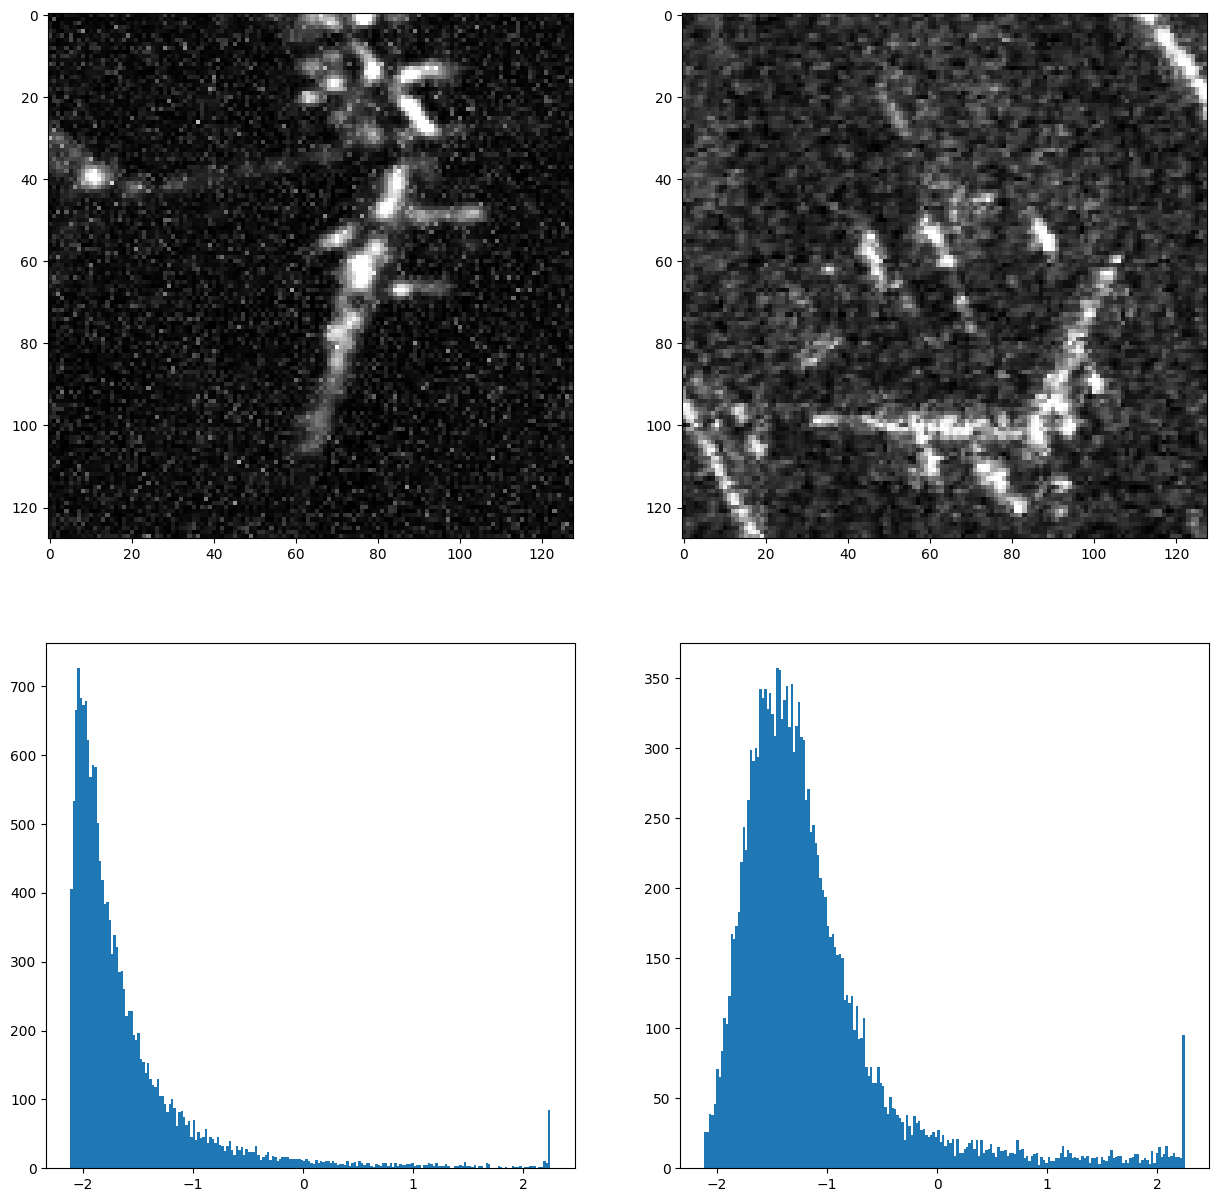

In [21]:
fig, ax = plt.subplots(2,2, figsize = (15,15))
ax[0,0].imshow(train_im[1,0], 'gray')
ax[0,1].imshow(val_im[0,0], 'gray')
ax[1,0].hist(train_im[1,0].ravel(), bins = 200)
ax[1,1].hist(val_im[0,0].ravel(), bins = 200)
plt.show()

In [38]:

model = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1)
# adjusting the model for custom classes
for param in model.parameters():
    param.requires_grad = False
num_features = model.classifier[-1].in_features
model.classifier[-1] = nn.Linear(num_features, num_classes)
model.classifier[2] = nn.Dropout(p=0.35, inplace=True)
for param in model.classifier.parameters():
    param.requires_grad = True

model.to(device)

MobileNetV3(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): SqueezeExcitation(
          (avgpool): AdaptiveAvgPool2d(output_size=1)
          (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
          (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
          (activation): ReLU()
          (scale_activation): Hardsigmoid()
        )
        (2): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(1, 1), 

## Loss And Optimizer

In [39]:
criterion = nn.CrossEntropyLoss()
param_to_update = [p for p in model.parameters() if p.requires_grad]
optimizer = optim.Adam(param_to_update, lr = learning_rate, weight_decay = 1e-3)

## Training loop

In [40]:
best_val_acc = 0.0
checkpoint = os.path.join(checkpoint_dir, checkpoint_name)
alpha = 0.1
w_acc = 0.7
w_loss  =0.3
warmup_epochs = 15
best_epoch = 0
best_score = -10
for epoch in range(num_epochs):
    model.train()

    running_loss = 0.0
    correct  =  0
    total = 0
    val_run_loss = 0

    for images, labels  in train_loader:
        images, labels = images.to(device) , labels.to(device)
        optimizer.zero_grad()

        output = model(images)
        loss = criterion(output, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()*images.size(0)
        _, predicted = torch.max(output.data, 1)
        total += labels.size(0)
        correct += (predicted==labels).sum().item()
    train_acc = 100*correct/total
    train_loss = running_loss/len(train_loader.dataset)
    writer.add_scalar("Train/loss", train_loss, epoch)
    writer.add_scalar("Train/Accuracy", train_acc , epoch)


    model.eval()
    val_correct = 0
    val_total = 0
    val_loss = 0
    ema_acc = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images ,labels = images.to(device), labels.to(device)
            outputs = model(images)
            v_loss = criterion(outputs, labels)
            val_run_loss += v_loss.item()*images.size(0)
            _ , predicted = torch.max(outputs.data,1)
            val_total += labels.size(0)
            val_correct += (predicted==labels).sum().item()
    val_loss = val_run_loss/len(val_loader.dataset)
    val_acc = 100*val_correct/val_total
    if epoch ==0:
        ema_acc = val_acc
    else:
        ema_acc = alpha*val_acc +(1-alpha)*ema_acc
    score = w_acc*ema_acc - w_loss*v_loss
    writer.add_scalar("Val/loss", val_loss, epoch)
    writer.add_scalar("Val/Accuracy", val_acc, epoch)
    writer.add_scalar("Val/ema_accuracy_0.2", ema_acc,epoch)
    writer.add_scalar("model/score", score, epoch)
    print(f"Epoch {epoch}/{num_epochs}")
    print(f"Train Loss: {train_loss:.4f}, Train acc: {train_acc: .2f}%")
    print(f"Val Loss {val_loss:.2f} Val Acc: {val_acc:.2f}%")
    if epoch>= warmup_epochs:
        if score > best_score:
            best_score=score
            best_val_acc = val_acc
            best_epoch = epoch
            torch.save(model.state_dict(), checkpoint)

print("training Complete. epoch accuracy, loss :", best_val_acc, val_loss)




Epoch 0/100
Train Loss: 0.5896, Train acc:  69.39%
Val Loss 0.86 Val Acc: 48.72%
Epoch 1/100
Train Loss: 0.4131, Train acc:  81.07%
Val Loss 0.79 Val Acc: 48.72%
Epoch 2/100
Train Loss: 0.3381, Train acc:  85.98%
Val Loss 0.73 Val Acc: 48.72%
Epoch 3/100
Train Loss: 0.2724, Train acc:  89.72%
Val Loss 0.66 Val Acc: 48.72%
Epoch 4/100
Train Loss: 0.2611, Train acc:  90.19%
Val Loss 0.59 Val Acc: 51.28%
Epoch 5/100
Train Loss: 0.2517, Train acc:  89.49%
Val Loss 0.55 Val Acc: 58.97%
Epoch 6/100
Train Loss: 0.2152, Train acc:  91.59%
Val Loss 0.53 Val Acc: 61.54%
Epoch 7/100
Train Loss: 0.2330, Train acc:  91.12%
Val Loss 0.56 Val Acc: 61.54%
Epoch 8/100
Train Loss: 0.2642, Train acc:  88.55%
Val Loss 0.60 Val Acc: 56.41%
Epoch 9/100
Train Loss: 0.2024, Train acc:  93.46%
Val Loss 0.69 Val Acc: 53.85%
Epoch 10/100
Train Loss: 0.2062, Train acc:  92.76%
Val Loss 0.79 Val Acc: 46.15%
Epoch 11/100
Train Loss: 0.1902, Train acc:  92.76%
Val Loss 0.88 Val Acc: 43.59%
Epoch 12/100
Train Loss: 0